<a href="https://colab.research.google.com/github/100car/ITStep-AI/blob/superwised_learning/%D0%94%D0%97_%D0%BE%D0%B1%D1%80%D0%BE%D0%B1%D0%BA%D0%B0_%D0%B4%D0%B0%D0%BD%D0%B8%D1%85.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/HalyshAnton/IT-Step-Pyton-AI/main/module3/data/House_Rent_Dataset.csv", index_col="Unnamed: 0")

[Інформація про дані](https://www.kaggle.com/datasets/iamsouravbanerjee/house-rent-prediction-dataset)

In [19]:
df.head(10)

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2.0,10000.0,1100.0,Ground out of 2,NaN,NaN,Kolkata,Unfurnished,Bachelors/Family,2.0,Contact Owner
1,2022-05-13,2.0,20000.0,800.0,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1.0,NaN
2,2022-05-16,2.0,17000.0,1000.0,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1.0,Contact Owner
3,2022-07-04,2.0,10000.0,800.0,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1.0,Contact Owner
4,NaN,2.0,7500.0,850.0,1 out of 2,Carpet Area,NaN,Kolkata,Unfurnished,Bachelors,1.0,Contact Owner
5,2022-04-29,2.0,7000.0,600.0,Ground out of 1,Super Area,Thakurpukur,Kolkata,Unfurnished,Bachelors/Family,2.0,Contact Owner
6,2022-06-21,2.0,10000.0,700.0,Ground out of 4,Super Area,Malancha,Kolkata,Unfurnished,Bachelors,NaN,Contact Agent
7,2022-06-21,1.0,5000.0,250.0,1 out of 2,Super Area,Malancha,NaN,Unfurnished,Bachelors,1.0,Contact Agent
8,2022-06-07,2.0,26000.0,800.0,1 out of 2,Carpet Area,"Palm Avenue Kolkata, Ballygunge",Kolkata,Unfurnished,Bachelors,2.0,Contact Agent
9,2022-06-20,2.0,NaN,1000.0,1 out of 3,Carpet Area,Natunhat,Kolkata,Semi-Furnished,Bachelors/Family,2.0,Contact Owner


# Завдання 1
Виведіть інформацію про таблицю(кількість рядків та стовпчиків та типи даних). Також виведіть кількість пропущених значень по стовпчиках

In [5]:
df.shape

(4746, 12)

In [13]:
4768**0.5

69.05070600652827

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Posted On          4379 non-null   object 
 1   BHK                4342 non-null   float64
 2   Rent               4369 non-null   float64
 3   Size               4402 non-null   float64
 4   Floor              4380 non-null   object 
 5   Area Type          4390 non-null   object 
 6   Area Locality      4347 non-null   object 
 7   City               4388 non-null   object 
 8   Furnishing Status  4395 non-null   object 
 9   Tenant Preferred   4372 non-null   object 
 10  Bathroom           4387 non-null   float64
 11  Point of Contact   4372 non-null   object 
dtypes: float64(4), object(8)
memory usage: 611.1+ KB


`BHK`: Number of Bedrooms, Hall, Kitchen. Кількість спалень, вітальня (зал), кухня.

`Rent`: Rent of the Houses/Apartments/Flats. Орендна плата за будинки/апартаменти/квартири.

`Size`: Size of the Houses/Apartments/Flats in Square Feet. Площа будинків/апартаментів/квартир у квадратних футах.

`Floor`: Houses/Apartments/Flats situated in which Floor and Total Number of Floors (Example: Ground out of 2, 3 out of 5, etc.) На якому поверсі розташоване житло та загальна кількість поверхів (наприклад: перший із 2, 3 із 5 тощо).

`Area Type`: Size of the Houses/Apartments/Flats calculated on either Super Area or Carpet Area or Build Area. Тип площі: розрахунок за Super Area або Carpet Area, або Built-up Area.

`Area Locality`: Locality of the Houses/Apartments/Flats. Район/локація, де розташоване житло.

`City`: City where the Houses/Apartments/Flats are Located. Місто, де розташоване житло.

`Furnishing Status`: Furnishing Status of the Houses/Apartments/Flats, either it is Furnished or Semi-Furnished or Unfurnished. Статус меблювання: мебльоване / частково мебльоване / без меблів.

`Tenant Preferred`: Type of Tenant Preferred by the Owner or Agent. Бажаний тип орендаря (кого віддає перевагу власник або агент).

`Bathroom`: Number of Bathrooms. Кількість санвузлів (ванних кімнат).

`Point of Contact`: Whom should you contact for more information regarding the Houses/Apartments/Flats. Контактна особа: з ким зв’язатися для отримання додаткової інформації про житло.

In [23]:
df.describe()

,BHK,Rent,Size,Bathroom
count,4342.000000,4.369000e+03,4402.000000,4387.000000
mean,2.082220,3.461306e+04,967.214675,1.970139
std,0.827656,7.740818e+04,636.118893,0.886784
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


# Завдання 2
Виведіть гістограми для всіх числових стовпчиків

Text(0.5, 0, 'Кількість кімнат')

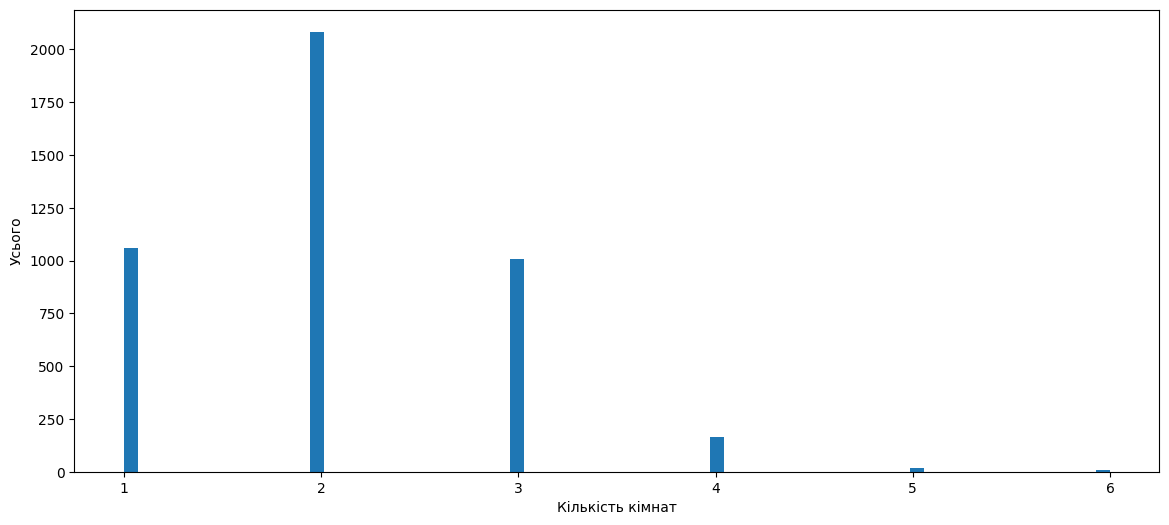

In [21]:
ax = df['BHK'].plot(kind='hist',    # тип діаграми hist
                             bins=69,        # кількість стовпчиків
                             figsize=(14,6)  # розмір зображення(в дюймах)
                             )
ax.set_ylabel('Усього')
ax.set_xlabel('Кількість кімнат')

Text(0.5, 0, 'Орендна плата')

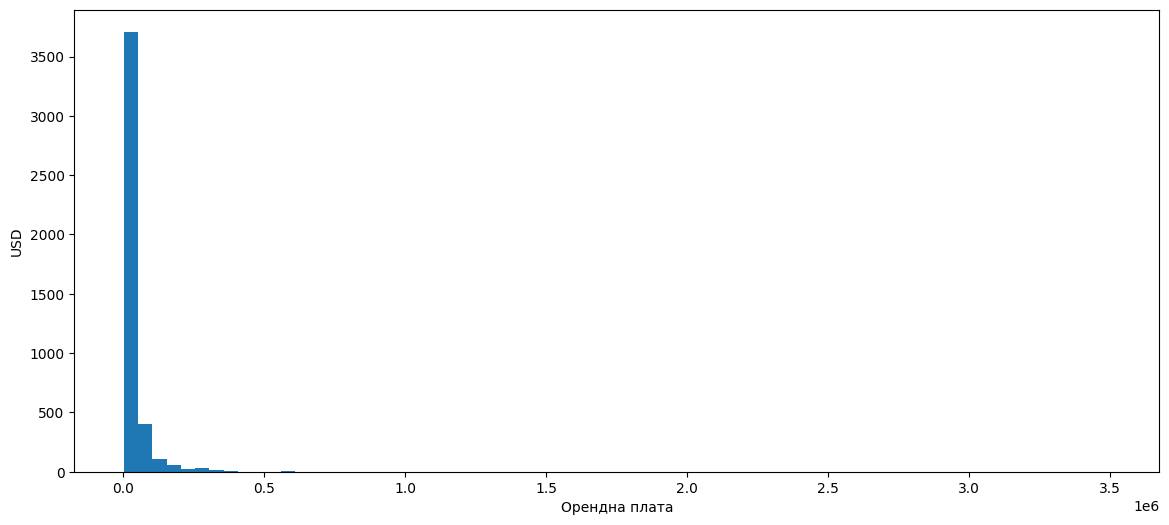

In [22]:
ax = df['Rent'].plot(kind='hist',    # тип діаграми hist
                             bins=69,        # кількість стовпчиків
                             figsize=(14,6)  # розмір зображення(в дюймах)
                             )
ax.set_ylabel('USD')
ax.set_xlabel('Орендна плата')

# Завдання 3
Виведіть ящик з вусами для всіх числових стовпчиків. Де потрібно очистіть викиди

Text(0.5, 0, 'Площа')

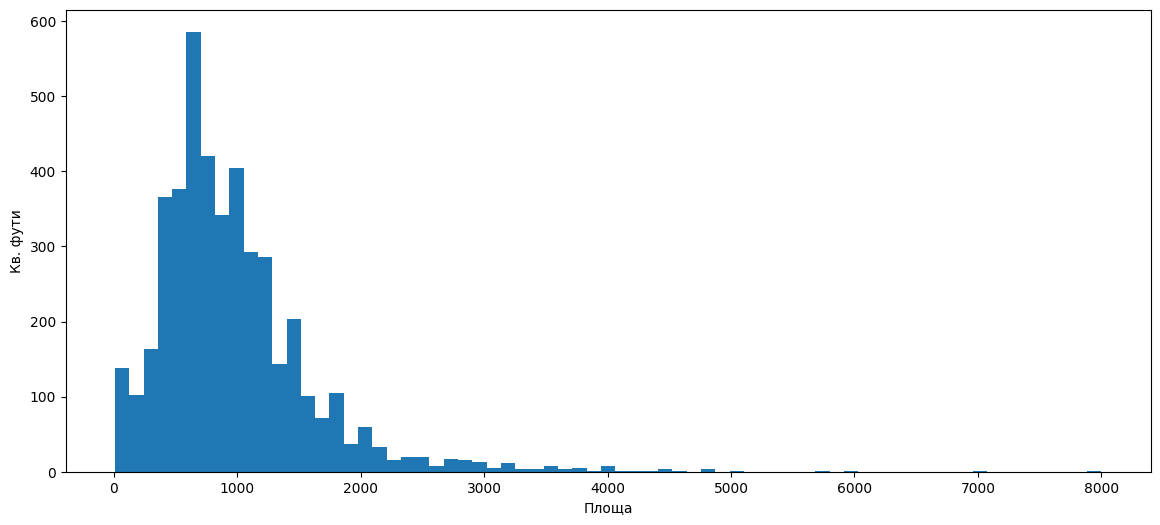

In [24]:
ax = df['Size'].plot(kind='hist',    # тип діаграми hist
                             bins=69,        # кількість стовпчиків
                             figsize=(14,6)  # розмір зображення(в дюймах)
                             )
ax.set_ylabel('Кв. фути')
ax.set_xlabel('Площа')

Text(0.5, 0, 'Кількість санвузлів')

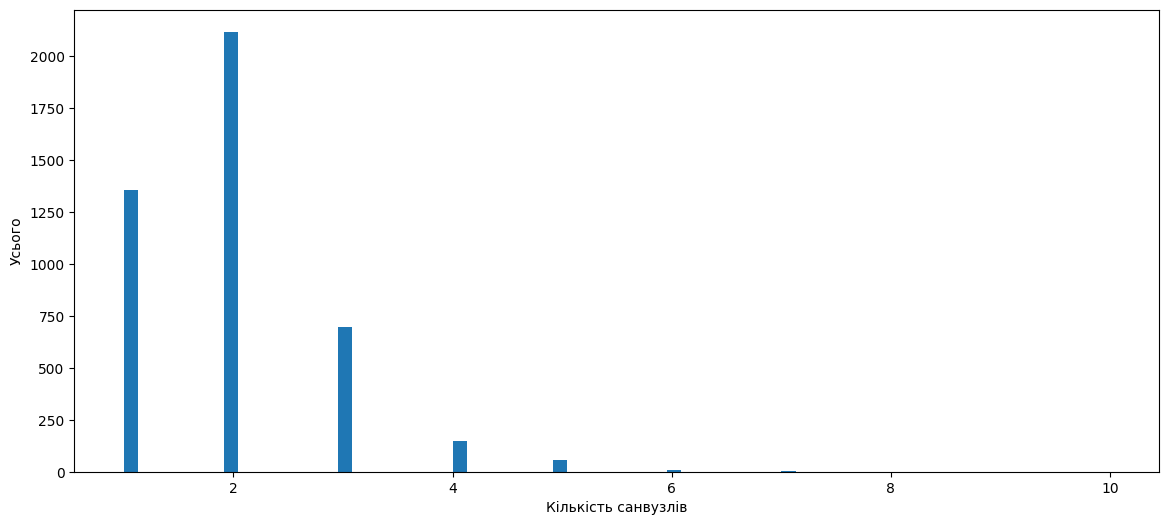

In [25]:
ax = df['Bathroom'].plot(kind='hist',    # тип діаграми hist
                             bins=69,        # кількість стовпчиків
                             figsize=(14,6)  # розмір зображення(в дюймах)
                             )
ax.set_ylabel('Усього')
ax.set_xlabel('Кількість санвузлів')

# Завдання 4
Створіть Pipeline для обробки даних:
створюємо "ящики з вусами", проводимо очистку даних.


<Axes: >

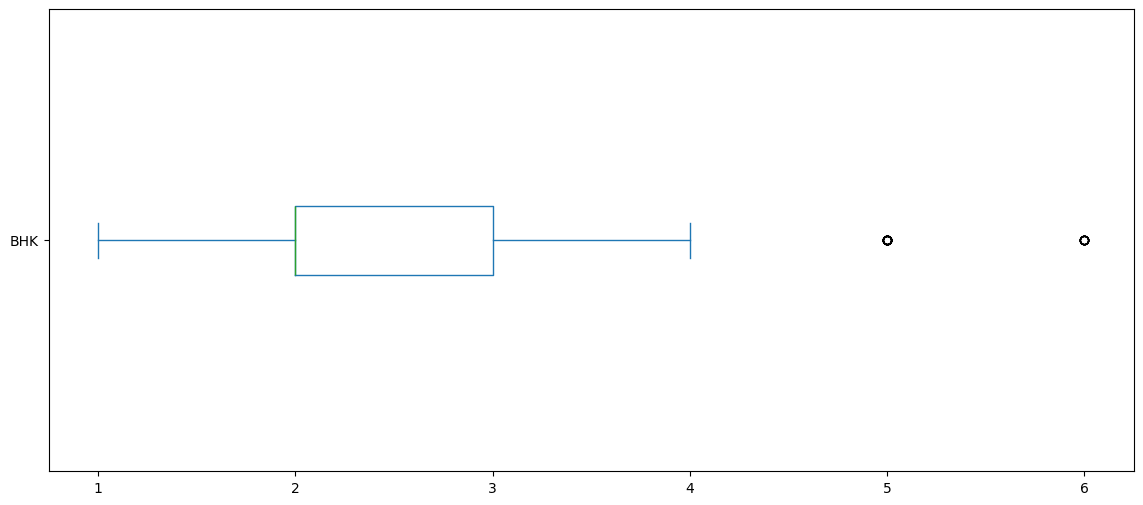

In [26]:

df['BHK'].plot(kind='box', vert=False, figsize=(14,6))

<Axes: >

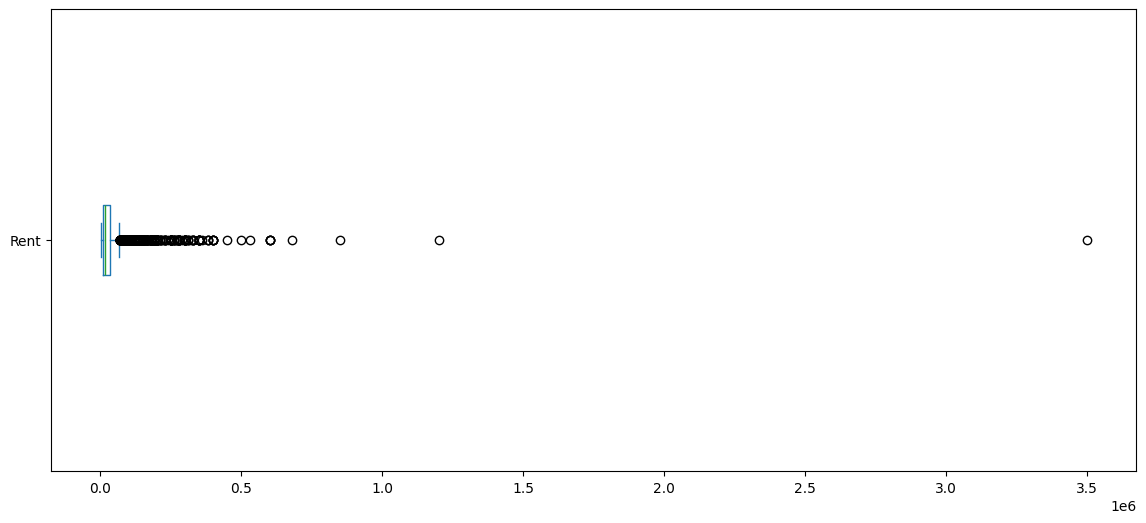

In [27]:
df['Rent'].plot(kind='box', vert=False, figsize=(14,6))

In [36]:
mask = df['Rent'] <  4e10
mask.sum()

np.int64(4369)

In [42]:
mask = df['Rent'].isna()
mask.sum()

np.int64(377)

In [43]:
df = df[~mask]

In [45]:
df.shape

(4369, 12)

In [51]:
mask = df['Rent'] <  0.8e6
mask.sum()

np.int64(4366)

In [52]:
df = df[mask]

<Axes: >

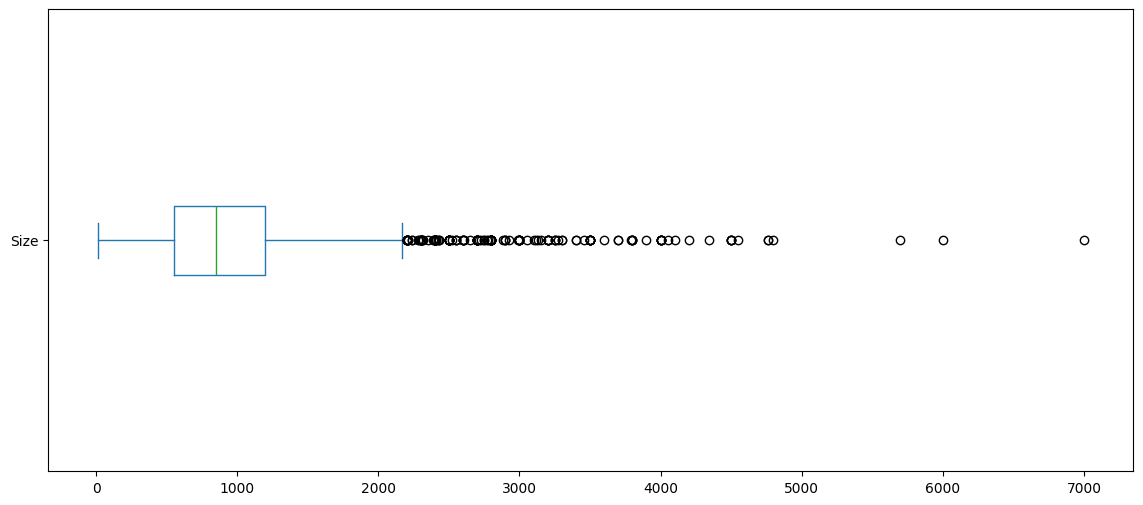

In [54]:
df['Size'].plot(kind='box', vert=False, figsize=(14,6))

In [55]:
mask = df['Size'] <  5000
mask.sum()

np.int64(4044)

In [56]:
mask = df['Size'].isna()
mask.sum()

np.int64(319)

In [57]:
df = df[~mask]

<Axes: >

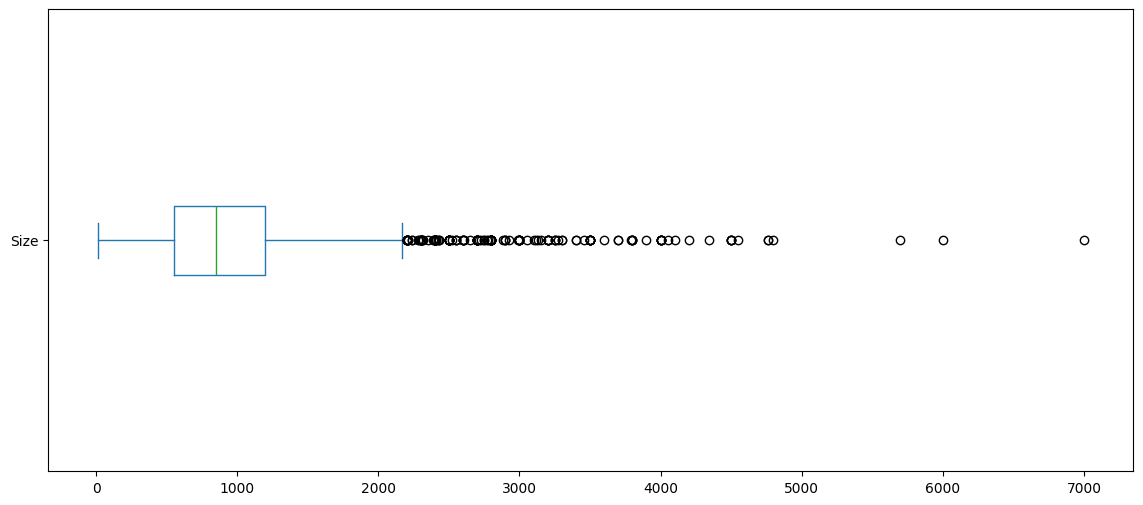

In [58]:
df['Size'].plot(kind='box', vert=False, figsize=(14,6))

In [59]:
mask = df['Size'] <  5000
mask.sum()

np.int64(4044)

In [61]:
df = df[mask]

<Axes: >

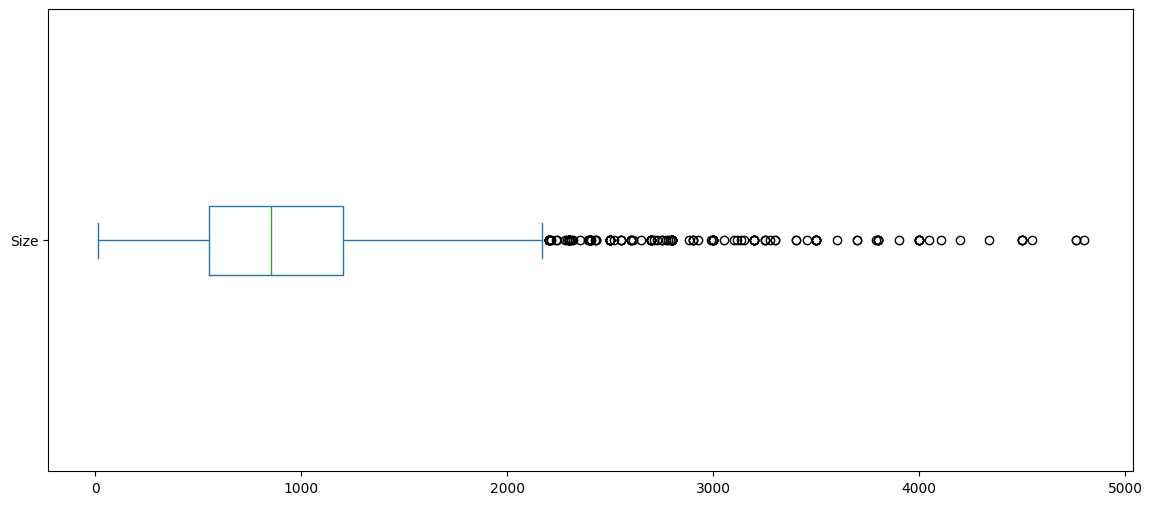

In [62]:
df['Size'].plot(kind='box', vert=False, figsize=(14,6))

<Axes: >

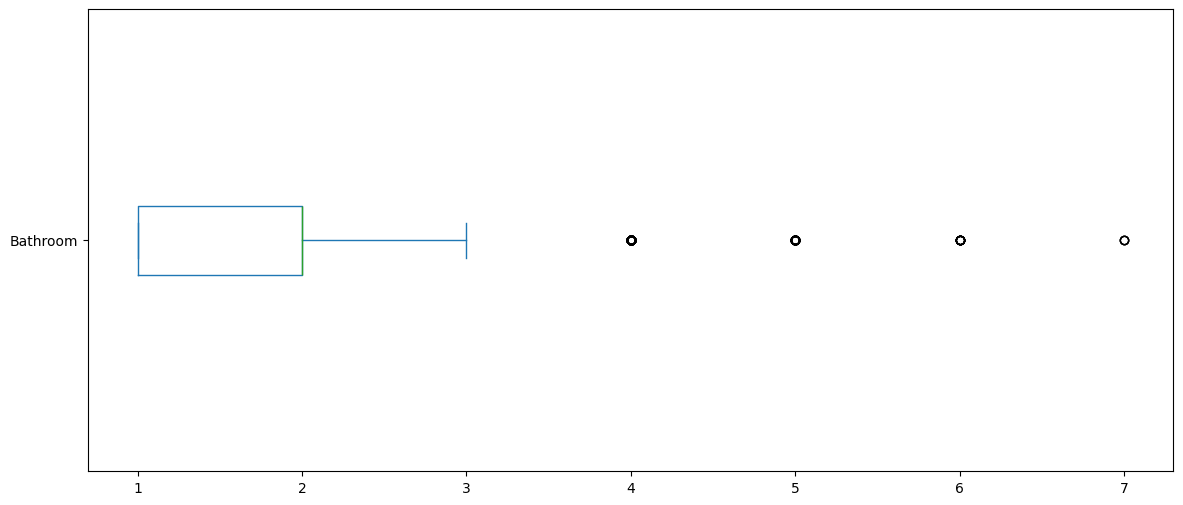

In [63]:
df['Bathroom'].plot(kind='box', vert=False, figsize=(14,6))

In [65]:
df.describe()

,BHK,Rent,Size,Bathroom
count,3710.000000,4044.000000,4044.000000,3735.000000
mean,2.081402,33100.630564,961.169139,1.968139
std,0.824833,52286.098762,609.202070,0.883280
min,1.000000,1200.000000,10.000000,1.000000
25%,2.000000,10000.000000,550.000000,1.000000
50%,2.000000,16000.000000,850.000000,2.000000
75%,3.000000,32000.000000,1200.000000,2.000000
max,6.000000,680000.000000,4800.000000,7.000000


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4044 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Posted On          3724 non-null   object 
 1   BHK                3710 non-null   float64
 2   Rent               4044 non-null   float64
 3   Size               4044 non-null   float64
 4   Floor              3729 non-null   object 
 5   Area Type          3733 non-null   object 
 6   Area Locality      3704 non-null   object 
 7   City               3747 non-null   object 
 8   Furnishing Status  3749 non-null   object 
 9   Tenant Preferred   3718 non-null   object 
 10  Bathroom           3735 non-null   float64
 11  Point of Contact   3730 non-null   object 
dtypes: float64(4), object(8)
memory usage: 410.7+ KB


In [70]:
mask = df['Point of Contact'].isna()
mask.sum()

np.int64(314)

In [71]:
df = df[~mask]

In [72]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 3730 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Posted On          3437 non-null   object 
 1   BHK                3423 non-null   float64
 2   Rent               3730 non-null   float64
 3   Size               3730 non-null   float64
 4   Floor              3436 non-null   object 
 5   Area Type          3440 non-null   object 
 6   Area Locality      3425 non-null   object 
 7   City               3459 non-null   object 
 8   Furnishing Status  3459 non-null   object 
 9   Tenant Preferred   3429 non-null   object 
 10  Bathroom           3448 non-null   float64
 11  Point of Contact   3730 non-null   object 
dtypes: float64(4), object(8)
memory usage: 378.8+ KB


Треба заглиблюватися в проблематику, але у ВСІХ 3730 рядків вказано основне:
`Rent і Size`: Площа будинку і за скільки здають.
Усе інше можна вияснити у Point of Contact.

In [73]:
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2.0,10000.0,1100.0,Ground out of 2,NaN,NaN,Kolkata,Unfurnished,Bachelors/Family,2.0,Contact Owner
2,2022-05-16,2.0,17000.0,1000.0,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1.0,Contact Owner
3,2022-07-04,2.0,10000.0,800.0,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1.0,Contact Owner
4,NaN,2.0,7500.0,850.0,1 out of 2,Carpet Area,NaN,Kolkata,Unfurnished,Bachelors,1.0,Contact Owner
5,2022-04-29,2.0,7000.0,600.0,Ground out of 1,Super Area,Thakurpukur,Kolkata,Unfurnished,Bachelors/Family,2.0,Contact Owner


Побудувати залежність 'Rent' від 'Size' Gemini запропонував. :)

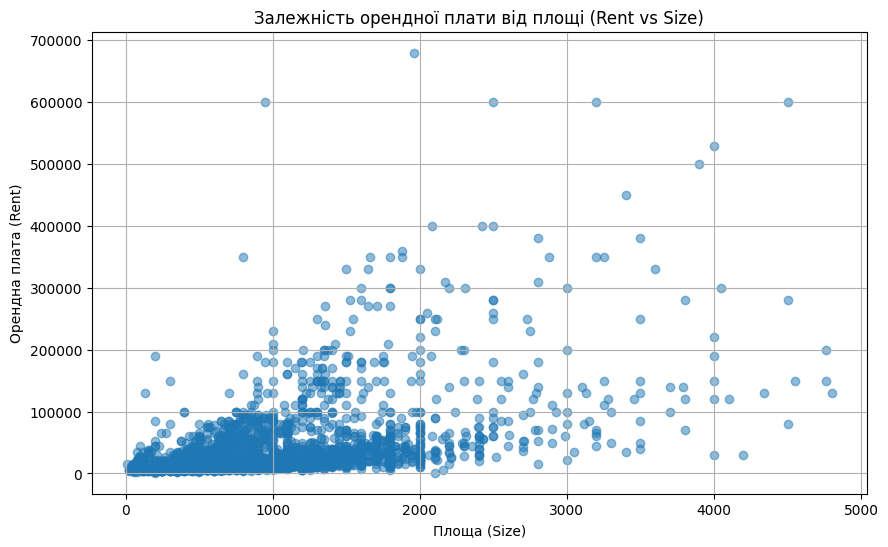

In [75]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Size'], df['Rent'], alpha=0.5)
plt.title('Залежність орендної плати від площі (Rent vs Size)')
plt.xlabel('Площа (Size)')
plt.ylabel('Орендна плата (Rent)')
plt.grid(True)
plt.show()